Successfully loaded Wave 2 (2008) Cleaned: 3210 rows


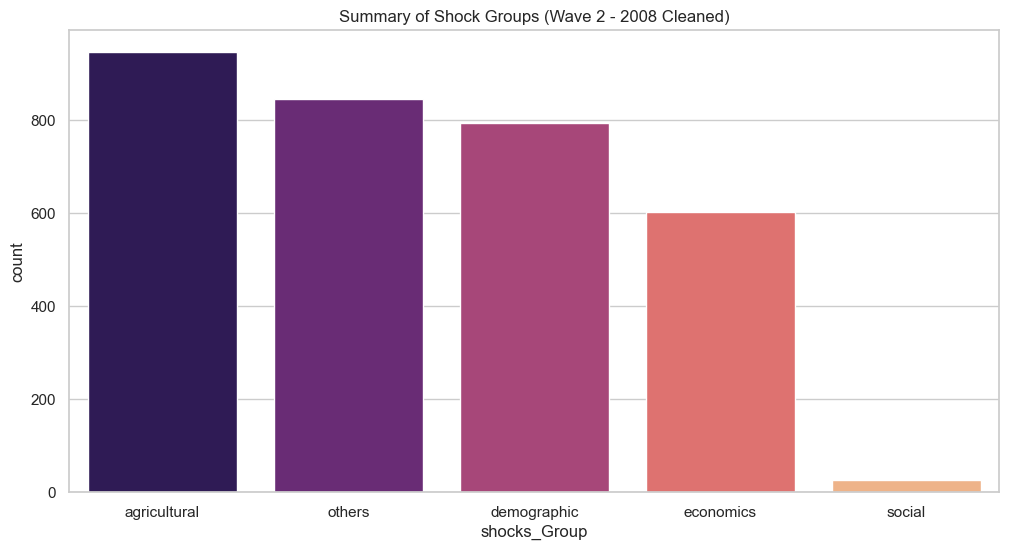

✅ Finished: shocks_2008_cleaned_final.csv is processed and ready for panel analysis.


In [2]:
# ==============================================================================
# STEP 1: SETUP & OPTIMIZATION
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# STEP 2: DATA LOADING (Wave 2 - 2008 Cleaned)
# ==============================================================================
file_2008 = 'wave-2-shocksclean.dta'
# ใช้ convert_categoricals=False เพื่อป้องกันปัญหาชื่อ Label ซ้ำใน Stata Metadata
df_08 = pd.read_stata(file_2008, convert_categoricals=False)

print(f"Successfully loaded Wave 2 (2008) Cleaned: {len(df_08)} rows")

# ==============================================================================
# STEP 3: DATA CLEANING (Standard Research Logic)
# ==============================================================================
def clean_wave2_final(df):
    # จัดการรหัสค่าว่างมาตรฐาน Stata (-9, -99)
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # จัดการมูลค่าความเสียหาย (_x31005a)
    if '_x31005a' in df.columns:
        # ลบคำว่า 'none', ช่องว่าง และแปลงเป็นตัวเลข (Float)
        df['_x31005a'] = df['_x31005a'].astype(str).str.replace('none', '0', case=False).str.strip()
        df['_x31005a'] = pd.to_numeric(df['_x31005a'], errors='coerce').fillna(0)
    
    return df

df_08 = clean_wave2_final(df_08)

# ==============================================================================
# STEP 4: COPING STRATEGY HARMONIZATION (สร้างมิติให้เท่ากับปี 2022)
# ==============================================================================
# Mapping รหัสการรับมือให้เข้ากลุ่มมาตรฐาน (Common Harmonized Groups)
coping_map_08 = {
    11: 'sold_assets', 12: 'sold_assets', 13: 'sold_assets', 14: 'sold_assets',
    15: 'used_savings', 16: 'used_insurance',
    17: 'borrowed_informal', 18: 'borrowed_informal', 19: 'borrowed_informal', 20: 'borrowed_informal',
    21: 'borrowed_formal', 22: 'borrowed_formal', 23: 'borrowed_formal', 
    28: 'gov_help', 29: 'gov_help', 30: 'relatives_help'
}

coping_categories = ['sold_assets', 'used_savings', 'used_insurance', 'borrowed_informal', 'borrowed_formal', 'gov_help']
for cat in coping_categories:
    df_08[f'coping_{cat}'] = 0

# ตรวจสอบการรับมือจากทั้ง 3 ลำดับเหตุการณ์ (_x31008, _x31009, _x31010)
for col in ['_x31008', '_x31009', '_x31010']:
    if col in df_08.columns:
        for code, cat_name in coping_map_08.items():
            df_08.loc[df_08[col] == code, f'coping_{cat_name}'] = 1

# ==============================================================================
# STEP 4.1: SHOCK MAPPING & CATEGORIZATION (Fixed Definition)
# ==============================================================================
# นิยาม Mapping สำหรับปี 2008 (ป้องกัน Error Name Not Defined)
shock_map_08 = {
    10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
    1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
    5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
    8: 'social', 70: 'social', 77: 'economics'
}

# สร้างตัวแปรวิเคราะห์ที่ใช้ชื่อเดียวกันทุก Wave
df_08['shocks_Group'] = df_08['_x31002'].map(shock_map_08).fillna('others')
df_08['survey_year'] = 2008

# ==============================================================================
# STEP 5: EXPORT & VISUALIZATION
# ==============================================================================
output_file = 'shocks_2008_cleaned_final.csv'
df_08.to_csv(output_file, index=False)

# แสดงผลสรุปด้วยกราฟ
sns.countplot(data=df_08, x='shocks_Group', palette='magma', order=df_08['shocks_Group'].value_counts().index)
plt.title('Summary of Shock Groups (Wave 2 - 2008 Cleaned)')
plt.show()

print(f"✅ Finished: {output_file} is processed and ready for panel analysis.")